# Layout guides: constrained layout + tight layout

📄 Sources:
- https://matplotlib.org/stable/users/explain/axes/constrainedlayout_guide.html (45 min)
- https://matplotlib.org/stable/users/explain/axes/tight_layout_guide.html (15 min)

*Constrained layout* automatically adjusts subplots so that tick labels, legends and colorbars don't overlap, while keeping the layout you asked for. It is like *tight layout* but much more flexible (colorbars on several Axes, subfigures, mosaics, aligned spines).

Turn it on **before** adding Axes, in one of two ways:

```python
plt.subplots(layout="constrained")                  # per figure (preferred)
plt.rcParams['figure.constrained_layout.use'] = True # globally
```

> ⚠️ Calling `tight_layout()` turns constrained layout **off**.

**Skipped (as planned):** rcParams details beyond one example, manually setting positions, Debugging, Notes on the algorithm.

# Part A: Constrained layout guide

## Simple example

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec

print("matplotlib", mpl.__version__)

# Settings used throughout the docs page
plt.rcParams['savefig.facecolor'] = "0.8"
plt.rcParams['figure.figsize'] = 4.5, 4.
plt.rcParams['figure.max_open_warning'] = 50


def example_plot(ax, fontsize=12, hide_labels=False):
    """Draw a tiny line plot with (optionally big) labels and a title."""
    ax.plot([1, 2])

    ax.locator_params(nbins=3)   # at most ~3 ticks per axis
    if hide_labels:
        ax.set_xticklabels([])
        ax.set_yticklabels([])
    else:
        ax.set_xlabel('x-label', fontsize=fontsize)
        ax.set_ylabel('y-label', fontsize=fontsize)
        ax.set_title('Title', fontsize=fontsize)

matplotlib 3.11.2


With the default positioning, big titles, axis labels or tick labels can go **outside** the figure and get clipped:

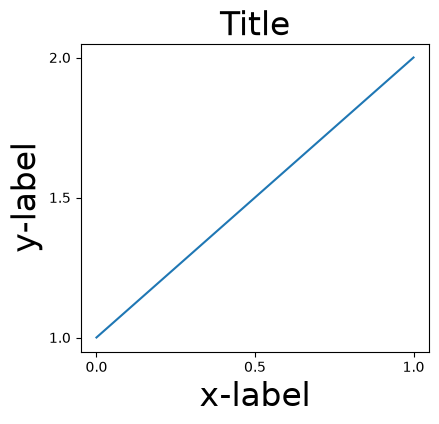

In [2]:
fig, ax = plt.subplots(layout=None)   # no layout engine
example_plot(ax, fontsize=24)

You could fix it by hand with `fig.subplots_adjust(...)`, but `layout="constrained"` does it automatically:

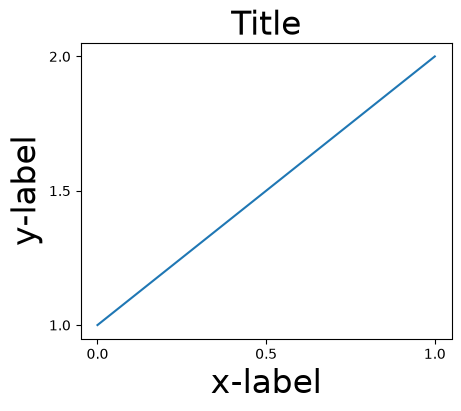

In [3]:
fig, ax = plt.subplots(layout="constrained")
example_plot(ax, fontsize=24)

With several subplots, labels of different Axes often overlap:

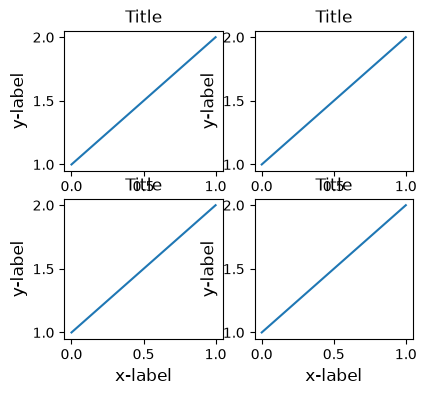

In [4]:
fig, axs = plt.subplots(2, 2, layout=None)
for ax in axs.flat:
    example_plot(ax)

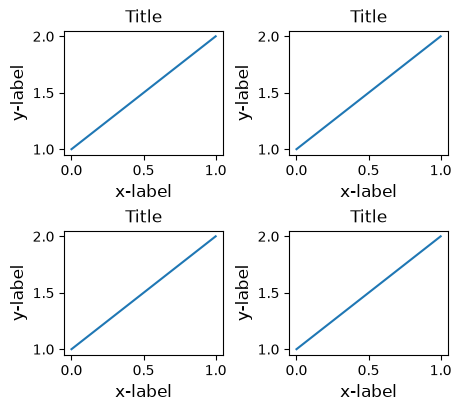

In [5]:
fig, axs = plt.subplots(2, 2, layout="constrained")   # same figure, no overlaps
for ax in axs.flat:
    example_plot(ax)

## Colorbars

A colorbar made with `fig.colorbar` needs room. Constrained layout makes that room automatically.

(The docs use one dict of `pcolormesh` keyword arguments, `pc_kwargs`, so all the calls stay consistent.)

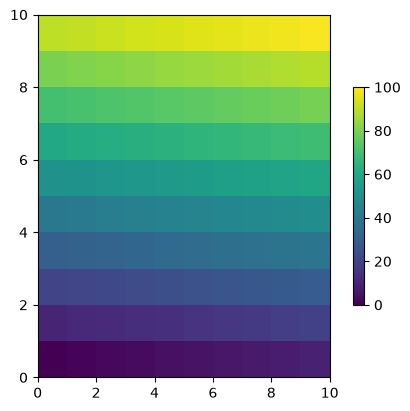

In [6]:
arr = np.arange(100).reshape((10, 10))
norm = mcolors.Normalize(vmin=0., vmax=100.)
# this makes all pcolormesh calls consistent:
pc_kwargs = {'rasterized': True, 'cmap': 'viridis', 'norm': norm}

fig, ax = plt.subplots(figsize=(4, 4), layout="constrained")
im = ax.pcolormesh(arr, **pc_kwargs)
fig.colorbar(im, ax=ax, shrink=0.6)

Pass a **list of Axes** to `ax=` and the colorbar takes space from all of them (one shared colorbar):

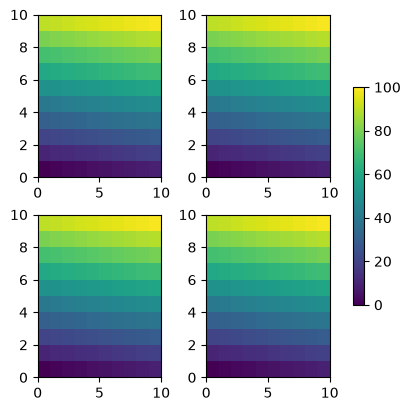

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(4, 4), layout="constrained")
for ax in axs.flat:
    im = ax.pcolormesh(arr, **pc_kwargs)
fig.colorbar(im, ax=axs, shrink=0.6)   # one colorbar for the whole grid

Pass a list of Axes from *inside* a grid and the colorbar steals space there, leaving a gap, but all subplots stay the same size:

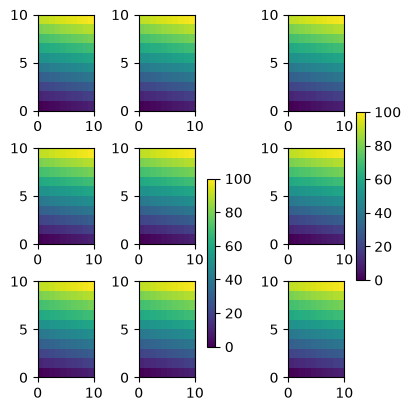

In [8]:
fig, axs = plt.subplots(3, 3, figsize=(4, 4), layout="constrained")
for ax in axs.flat:
    im = ax.pcolormesh(arr, **pc_kwargs)
fig.colorbar(im, ax=axs[1:, 1], shrink=0.8)   # next to the middle column, bottom two rows
fig.colorbar(im, ax=axs[:, -1], shrink=0.6)   # next to the last column

## Suptitle

Constrained layout also makes room for `fig.suptitle` (a title for the whole figure).

Text(0.5, 0.98, 'Big Suptitle')

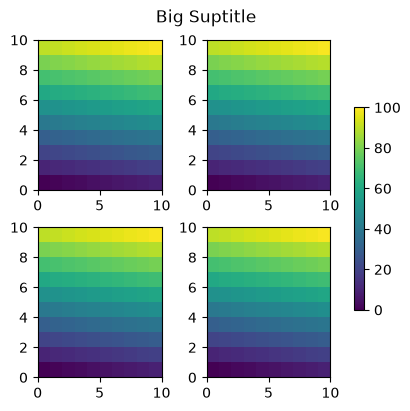

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(4, 4), layout="constrained")
for ax in axs.flat:
    im = ax.pcolormesh(arr, **pc_kwargs)
fig.colorbar(im, ax=axs, shrink=0.6)
fig.suptitle('Big Suptitle')

## Legends

Legends can sit **outside** their Axes. Constrained layout handles this for `ax.legend()` (not for `fig.legend()` yet).
`bbox_to_anchor=(0.8, 0.5)` with `loc='center left'` means: put the legend's centre-left point at 80% across and 50% up the Axes.

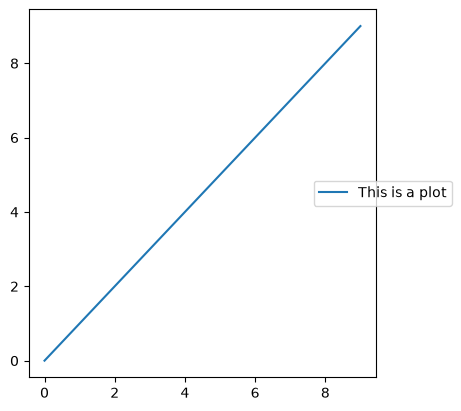

In [10]:
fig, ax = plt.subplots(layout="constrained")
ax.plot(np.arange(10), label='This is a plot')
ax.legend(loc='center left', bbox_to_anchor=(0.8, 0.5))

But in a subplot layout this **steals space** from that subplot:

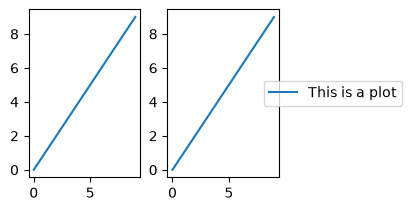

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(4, 2), layout="constrained")
axs[0].plot(np.arange(10))
axs[1].plot(np.arange(10), label='This is a plot')
axs[1].legend(loc='center left', bbox_to_anchor=(0.8, 0.5))   # right subplot shrinks to make room

To stop a legend from stealing space: `leg.set_in_layout(False)`. It may then be cropped on screen, but you can still save it fully with `bbox_inches='tight'` if you switch it back on and freeze the layout first.
The docs save to their own folder; here we save to `../Figures/`.

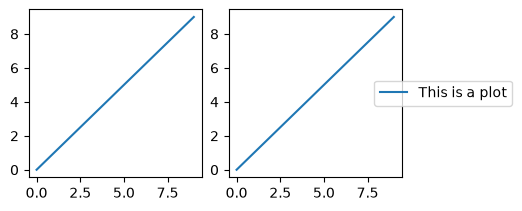

In [12]:
from pathlib import Path
Path("../Figures").mkdir(exist_ok=True)

fig, axs = plt.subplots(1, 2, figsize=(4, 2), layout="constrained")

axs[0].plot(np.arange(10))
axs[1].plot(np.arange(10), label='This is a plot')
leg = axs[1].legend(loc='center left', bbox_to_anchor=(0.8, 0.5))
leg.set_in_layout(False)
# trigger a draw so that constrained layout is executed once
# before we turn it off when printing....
fig.canvas.draw()
# we want the legend included in the bbox_inches='tight' calcs.
leg.set_in_layout(True)
# we don't want the layout to change at this point.
fig.set_layout_engine('none')
fig.savefig('../Figures/constrained_layout_1b.png', bbox_inches='tight', dpi=100)

The saved file looks like this (the legend is fully inside the saved image):

![saved legend 1](../Figures/constrained_layout_1b.png)

The **better way** around this awkwardness is `fig.legend(...)`, placed relative to one Axes with `bbox_transform=axs[1].transAxes`:

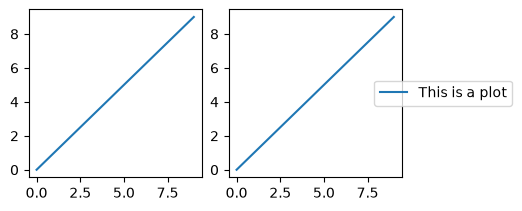

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(4, 2), layout="constrained")
axs[0].plot(np.arange(10))
lines = axs[1].plot(np.arange(10), label='This is a plot')
labels = [l.get_label() for l in lines]
leg = fig.legend(lines, labels, loc='center left',
                 bbox_to_anchor=(0.8, 0.5), bbox_transform=axs[1].transAxes)
fig.savefig('../Figures/constrained_layout_2b.png', bbox_inches='tight', dpi=100)

The saved file:

![saved legend 2](../Figures/constrained_layout_2b.png)

## Padding and spacing

- Horizontal: `w_pad` and `wspace`. Vertical: `h_pad` and `hspace`.
- `w_pad` / `h_pad` = the **minimum** space around each Axes, in **inches**.
- Change them with `fig.get_layout_engine().set(...)`.

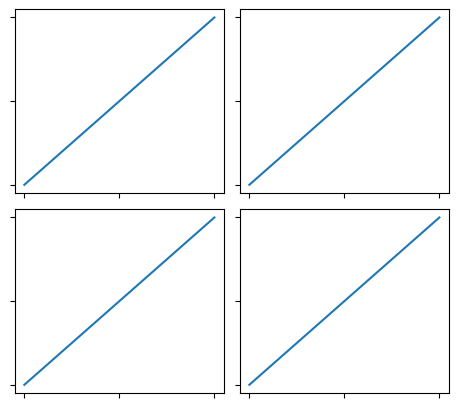

In [14]:
fig, axs = plt.subplots(2, 2, layout="constrained")
for ax in axs.flat:
    example_plot(ax, hide_labels=True)
fig.get_layout_engine().set(w_pad=4 / 72, h_pad=4 / 72, hspace=0,
                            wspace=0)   # 4 points of padding, no extra space between subplots

`wspace` / `hspace` = space **between** subplots, as a **fraction** of the subplot group's size. If they are smaller than the pads, the pads are used. Below, the edges stay the same as above but the gaps between subplots grow:

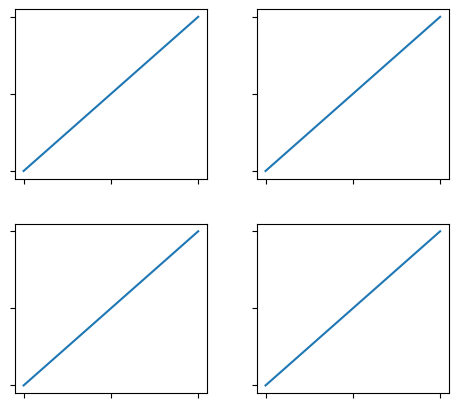

In [15]:
fig, axs = plt.subplots(2, 2, layout="constrained")
for ax in axs.flat:
    example_plot(ax, hide_labels=True)
fig.get_layout_engine().set(w_pad=4 / 72, h_pad=4 / 72, hspace=0.2,
                            wspace=0.2)

With more than two columns, `wspace` is **shared** between the gaps (here 0.2 / 2 = 0.1 per gap):

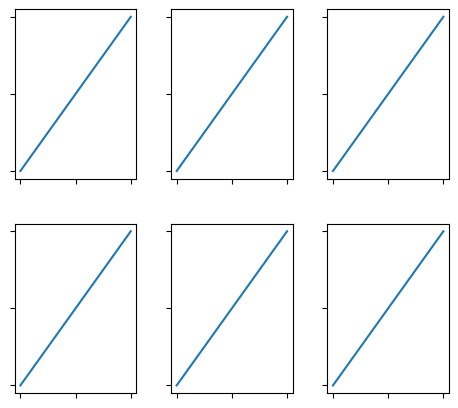

In [16]:
fig, axs = plt.subplots(2, 3, layout="constrained")
for ax in axs.flat:
    example_plot(ax, hide_labels=True)
fig.get_layout_engine().set(w_pad=4 / 72, h_pad=4 / 72, hspace=0.2,
                            wspace=0.2)

GridSpecs have their own `hspace`/`wspace`; if given, they win over constrained layout's values:

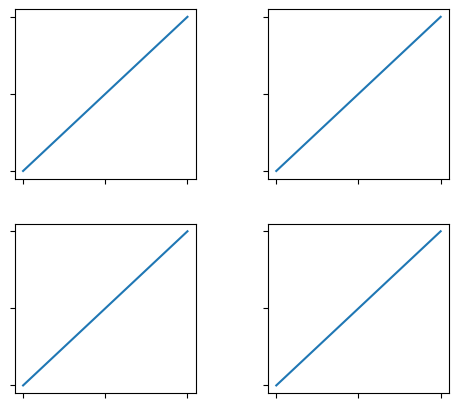

In [17]:
fig, axs = plt.subplots(2, 2, layout="constrained",
                        gridspec_kw={'wspace': 0.3, 'hspace': 0.2})
for ax in axs.flat:
    example_plot(ax, hide_labels=True)
# this has no effect because the space set in the gridspec trumps the
# space set in *constrained layout*.
fig.get_layout_engine().set(w_pad=4 / 72, h_pad=4 / 72, hspace=0.0,
                            wspace=0.0)

### Spacing with colorbars

A colorbar sits a distance `pad` from its parent (`pad` = a fraction of the parent's width). The gap to the next subplot is then `wspace`/`hspace`.

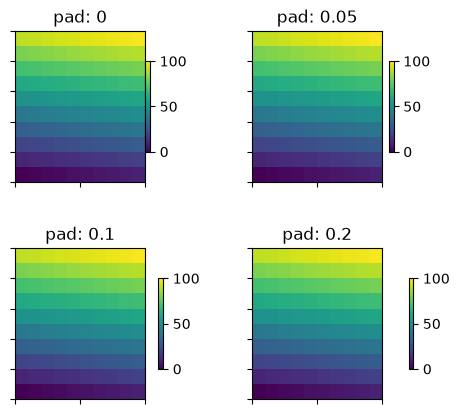

In [18]:
fig, axs = plt.subplots(2, 2, layout="constrained")
pads = [0, 0.05, 0.1, 0.2]
for pad, ax in zip(pads, axs.flat):
    pc = ax.pcolormesh(arr, **pc_kwargs)
    fig.colorbar(pc, ax=ax, shrink=0.6, pad=pad)   # increasing gap between Axes and colorbar
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_title(f'pad: {pad}')
fig.get_layout_engine().set(w_pad=2 / 72, h_pad=2 / 72, hspace=0.2,
                            wspace=0.2)

## Use with GridSpec

Constrained layout works with `subplots`, `subplot_mosaic`, or a `GridSpec` + `add_subplot`.

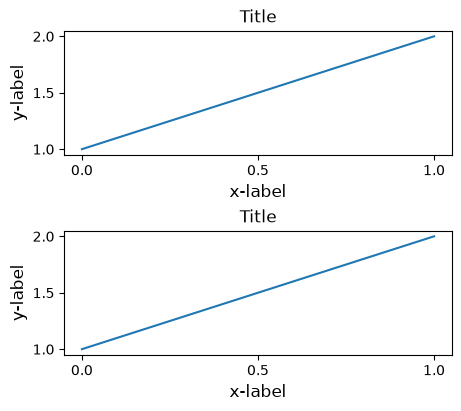

In [19]:
fig = plt.figure(layout="constrained")

gs1 = gridspec.GridSpec(2, 1, figure=fig)   # a 2-row, 1-column grid
ax1 = fig.add_subplot(gs1[0])
ax2 = fig.add_subplot(gs1[1])

example_plot(ax1)
example_plot(ax2)

More complex grids with `fig.add_gridspec` and `subgridspec` (a grid inside one cell of another grid):

Text(0.5, 0, 'x-label')

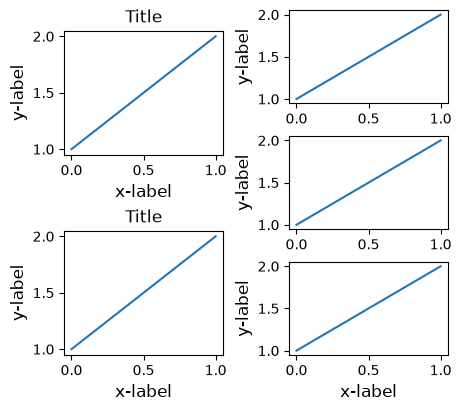

In [20]:
fig = plt.figure(layout="constrained")

gs0 = fig.add_gridspec(1, 2)       # outer grid: 1 row, 2 columns

gs1 = gs0[0].subgridspec(2, 1)     # left cell split into 2 rows
ax1 = fig.add_subplot(gs1[0])
ax2 = fig.add_subplot(gs1[1])

example_plot(ax1)
example_plot(ax2)

gs2 = gs0[1].subgridspec(3, 1)     # right cell split into 3 rows

for ss in gs2:
    ax = fig.add_subplot(ss)
    example_plot(ax)
    ax.set_title("")
    ax.set_xlabel("")

ax.set_xlabel("x-label", fontsize=12)

Above, the left and right columns don't line up vertically. To align top and bottom, put everything in **one** gridspec (and make the figure taller so the Axes don't collapse):

Text(0.5, 0.98, 'Overlapping Gridspecs')

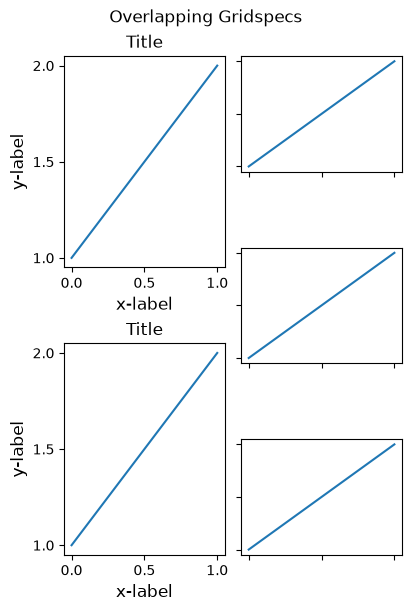

In [21]:
fig = plt.figure(figsize=(4, 6), layout="constrained")

gs0 = fig.add_gridspec(6, 2)     # 6 rows lets us split the left into 2 and the right into 3

ax1 = fig.add_subplot(gs0[:3, 0])   # rows 0-2, left column
ax2 = fig.add_subplot(gs0[3:, 0])   # rows 3-5, left column

example_plot(ax1)
example_plot(ax2)

ax = fig.add_subplot(gs0[0:2, 1])
example_plot(ax, hide_labels=True)
ax = fig.add_subplot(gs0[2:4, 1])
example_plot(ax, hide_labels=True)
ax = fig.add_subplot(gs0[4:, 1])
example_plot(ax, hide_labels=True)
fig.suptitle('Overlapping Gridspecs')

Two gridspecs so the colorbar only belongs to the right-hand set of plots:

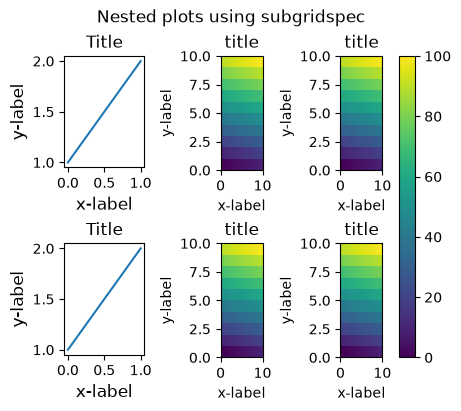

In [22]:
fig = plt.figure(layout="constrained")
gs0 = fig.add_gridspec(1, 2, figure=fig, width_ratios=[1, 2])
gs_left = gs0[0].subgridspec(2, 1)
gs_right = gs0[1].subgridspec(2, 2)

for gs in gs_left:
    ax = fig.add_subplot(gs)
    example_plot(ax)
axs = []
for gs in gs_right:
    ax = fig.add_subplot(gs)
    pcm = ax.pcolormesh(arr, **pc_kwargs)
    ax.set_xlabel('x-label')
    ax.set_ylabel('y-label')
    ax.set_title('title')
    axs += [ax]
fig.suptitle('Nested plots using subgridspec')
fig.colorbar(pcm, ax=axs)

The same result is simpler with `fig.subfigures` (independent "figures inside a figure"):

Text(0.5, 0.98, 'Nested plots using subfigures')

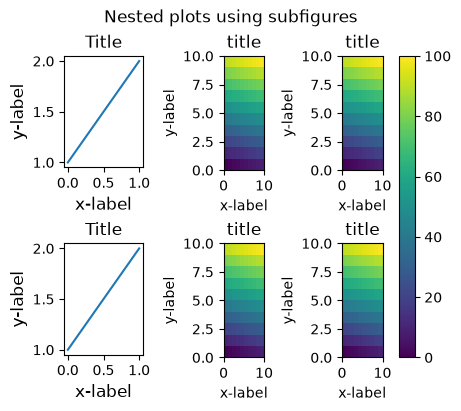

In [23]:
fig = plt.figure(layout="constrained")
sfigs = fig.subfigures(1, 2, width_ratios=[1, 2])

axs_left = sfigs[0].subplots(2, 1)
for ax in axs_left.flat:
    example_plot(ax)

axs_right = sfigs[1].subplots(2, 2)
for ax in axs_right.flat:
    pcm = ax.pcolormesh(arr, **pc_kwargs)
    ax.set_xlabel('x-label')
    ax.set_ylabel('y-label')
    ax.set_title('title')
fig.colorbar(pcm, ax=axs_right)
fig.suptitle('Nested plots using subfigures')

## Grids of fixed aspect-ratio Axes: "compressed" layout

Constrained layout works on the "original" grid positions. Axes with a fixed aspect ratio (e.g. images) get shortened on one side, leaving big gaps:

Text(0.5, 0.98, "fixed-aspect plots, layout='constrained'")

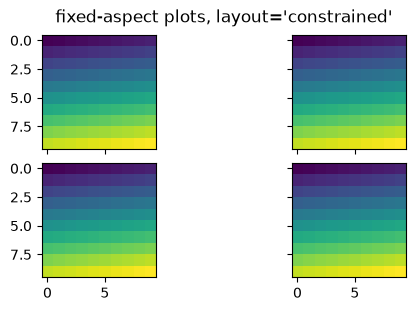

In [24]:
fig, axs = plt.subplots(2, 2, figsize=(5, 3),
                        sharex=True, sharey=True, layout="constrained")
for ax in axs.flat:
    ax.imshow(arr)
fig.suptitle("fixed-aspect plots, layout='constrained'")

`layout="compressed"` closes the gaps for simple grids:

Text(0.5, 0.98, "fixed-aspect plots, layout='compressed'")

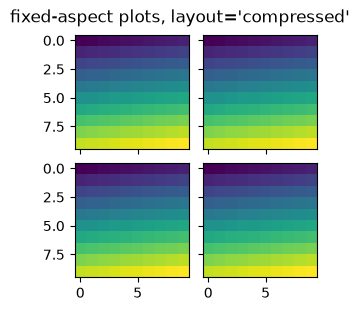

In [25]:
fig, axs = plt.subplots(2, 2, figsize=(5, 3),
                        sharex=True, sharey=True, layout='compressed')
for ax in axs.flat:
    ax.imshow(arr)
fig.suptitle("fixed-aspect plots, layout='compressed'")

Compressed layout also sizes colorbars to match a fixed-aspect parent. With `'constrained'` the colorbar is taller than the image:

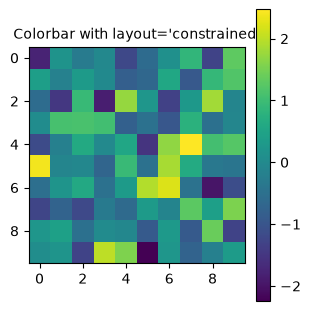

In [26]:
fig, ax = plt.subplots(layout='constrained', figsize=(3, 3))
pcm = ax.imshow(np.random.randn(10, 10), cmap='viridis')
ax.set_title("Colorbar with layout='constrained'", fontsize='medium')
fig.colorbar(pcm, ax=ax)

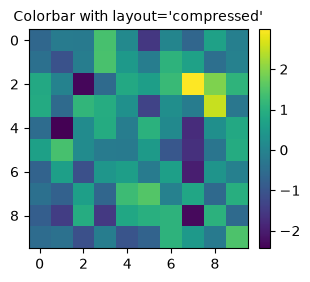

In [27]:
fig, ax = plt.subplots(layout='compressed', figsize=(3, 3))
pcm = ax.imshow(np.random.randn(10, 10), cmap='viridis')
ax.set_title("Colorbar with layout='compressed'", fontsize='medium')
fig.colorbar(pcm, ax=ax)   # colorbar height now matches the image

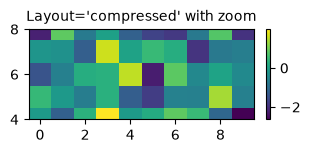

In [28]:
# If the Axes is zoomed or the figure resized, the colorbar follows the parent Axes
fig, ax = plt.subplots(layout='compressed', figsize=(3, 3))
pcm = ax.imshow(np.random.randn(10, 10), cmap='viridis')
ax.set_ylim([4, 8])
ax.set_title("Layout='compressed' with zoom", fontsize='medium')
fig.colorbar(pcm, ax=ax)

## Manually turning off constrained layout

Constrained layout re-runs on every draw. To keep its spacing but stop updates (useful for animations), draw once and then call `fig.set_layout_engine('none')`. It is also switched off during toolbar ZOOM/PAN.

## Limitations (skim)

### Incompatible functions
It works with `plt.subplot` only if **every call uses the same number of rows and columns**:

Text(0.5, 0.98, 'Homogeneous nrows, ncols')

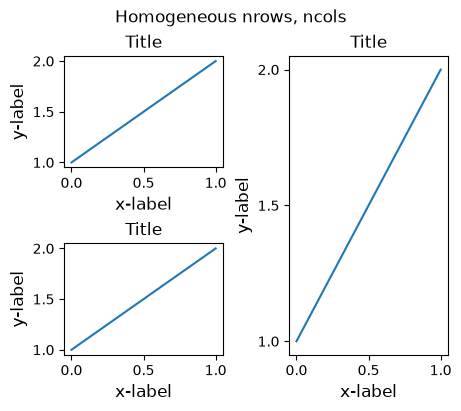

In [29]:
fig = plt.figure(layout="constrained")

ax1 = plt.subplot(2, 2, 1)
ax2 = plt.subplot(2, 2, 3)
# third Axes that spans both rows in second column:
ax3 = plt.subplot(2, 2, (2, 4))

example_plot(ax1)
example_plot(ax2)
example_plot(ax3)
plt.suptitle('Homogeneous nrows, ncols')

Text(0.5, 0.98, 'Mixed nrows, ncols')

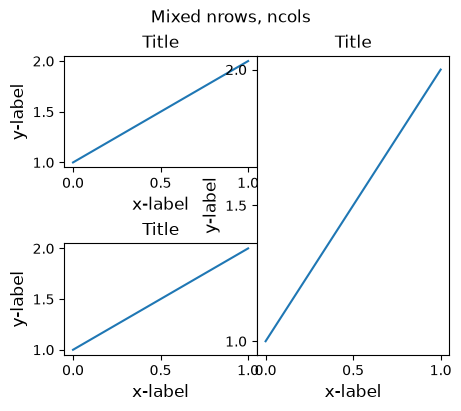

In [30]:
# Mixing (2, 2) and (1, 2) grids -> poor layout
fig = plt.figure(layout="constrained")

ax1 = plt.subplot(2, 2, 1)
ax2 = plt.subplot(2, 2, 3)
ax3 = plt.subplot(1, 2, 2)

example_plot(ax1)
example_plot(ax2)
example_plot(ax3)
plt.suptitle('Mixed nrows, ncols')

Text(0.5, 0.98, 'subplot2grid')

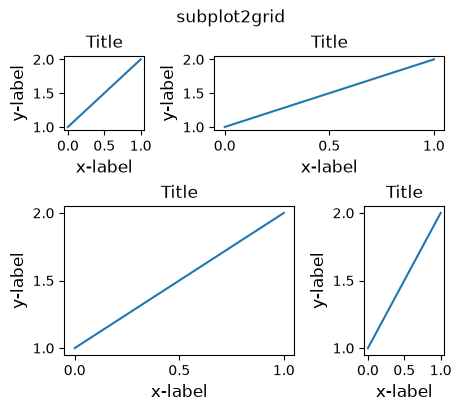

In [31]:
# subplot2grid works with the same rule: nrows/ncols must not change
fig = plt.figure(layout="constrained")

ax1 = plt.subplot2grid((3, 3), (0, 0))
ax2 = plt.subplot2grid((3, 3), (0, 1), colspan=2)
ax3 = plt.subplot2grid((3, 3), (1, 0), colspan=2, rowspan=2)
ax4 = plt.subplot2grid((3, 3), (1, 2), rowspan=2)

example_plot(ax1)
example_plot(ax2)
example_plot(ax3)
example_plot(ax4)
fig.suptitle('subplot2grid')

### Other caveats
- Only tick labels, axis labels, titles and legends are considered. Other artists can still be clipped or overlap.
- It assumes the extra space for labels doesn't depend on where the Axes is (usually true).
- Backends render fonts slightly differently, so results are not pixel-identical.
- An artist in Axes coordinates that extends past the Axes gives odd layouts; add it to the Figure with `fig.add_artist` instead.

---

# Part B: Tight layout guide

> 💡 `tight_layout` was the **first** layout engine. Constrained layout is more capable and should normally be used instead. Know what `tight_layout` does because you will see it everywhere in older code.

`tight_layout` adjusts subplot params so the subplots fit the figure. It only checks tick labels, axis labels and titles, and it runs **once, when you call it**.

## Simple example

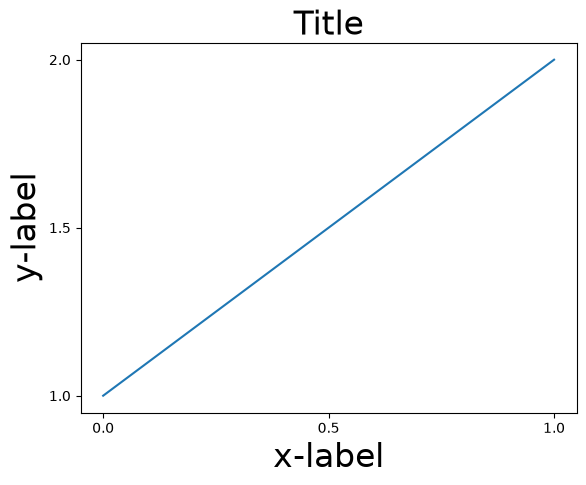

In [32]:
plt.rcParams['savefig.facecolor'] = "0.8"
plt.rcParams['figure.figsize'] = plt.rcParamsDefault['figure.figsize']   # back to default size for Part B


def example_plot(ax, fontsize=12):
    ax.plot([1, 2])

    ax.locator_params(nbins=3)
    ax.set_xlabel('x-label', fontsize=fontsize)
    ax.set_ylabel('y-label', fontsize=fontsize)
    ax.set_title('Title', fontsize=fontsize)

plt.close('all')
fig, ax = plt.subplots()
example_plot(ax, fontsize=24)   # labels get clipped

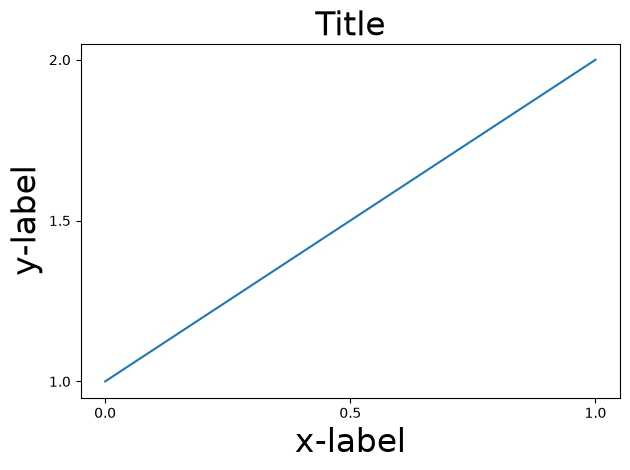

In [33]:
fig, ax = plt.subplots()
example_plot(ax, fontsize=24)
plt.tight_layout()   # adjusts once, at this moment

`tight_layout()` only adjusts when called. To re-run it on every draw use `fig.set_tight_layout(True)` or set `figure.autolayout` to `True` (that's what notebook 02 did).

With several subplots, labels overlap...

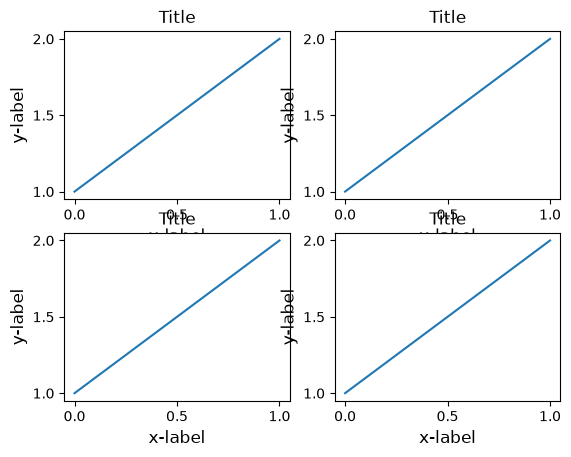

In [34]:
plt.close('all')

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2)
example_plot(ax1)
example_plot(ax2)
example_plot(ax3)
example_plot(ax4)

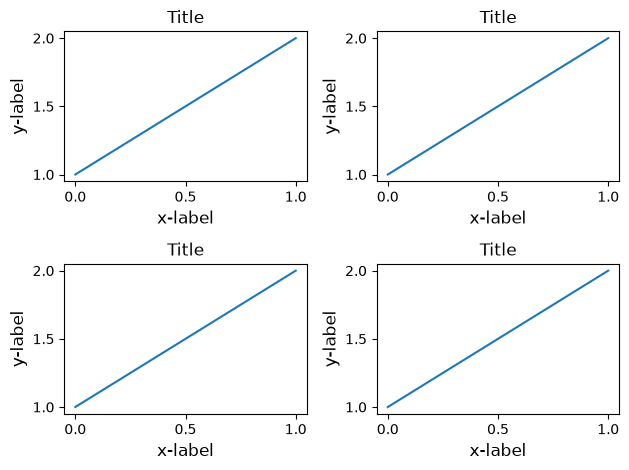

In [35]:
# ...and tight_layout also fixes the spacing between subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2)
example_plot(ax1)
example_plot(ax2)
example_plot(ax3)
example_plot(ax4)
plt.tight_layout()

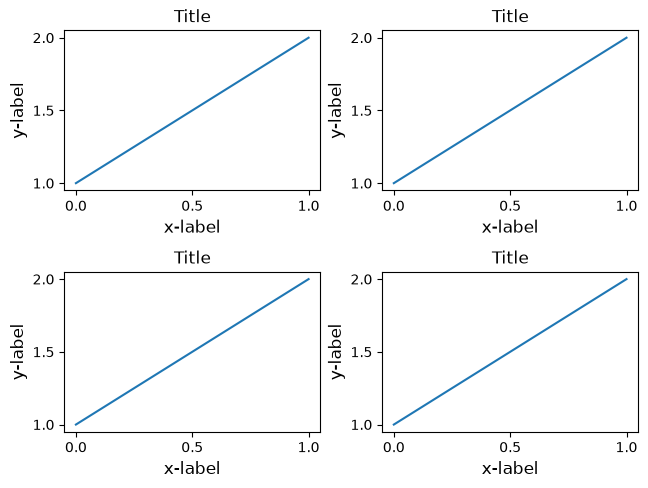

In [36]:
# pad, w_pad, h_pad: extra padding, as a fraction of the font size
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2)
example_plot(ax1)
example_plot(ax2)
example_plot(ax3)
example_plot(ax4)
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)

It also works when subplots have different sizes, as long as their grids are compatible (here two cells of a 2×2 grid + one cell of a 1×2 grid):

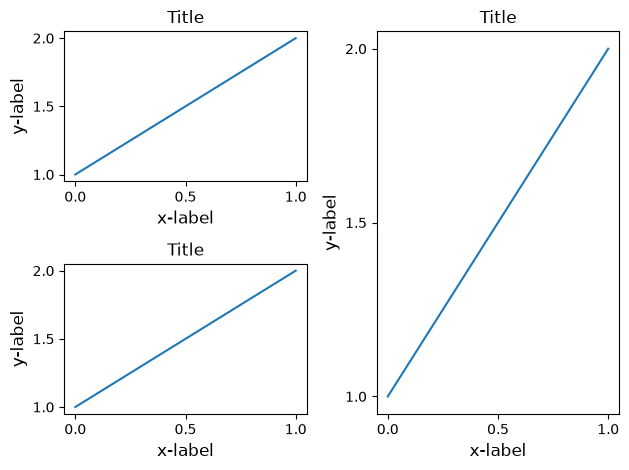

In [37]:
plt.close('all')
fig = plt.figure()

ax1 = plt.subplot(221)
ax2 = plt.subplot(223)
ax3 = plt.subplot(122)

example_plot(ax1)
example_plot(ax2)
example_plot(ax3)

plt.tight_layout()

## Caveats

- `tight_layout` considers **all artists** on the Axes by default. Exclude one with `artist.set_in_layout(False)`.
- It assumes the extra space needed doesn't depend on the Axes' original location.
- `pad=0` can clip text by a few pixels. Use `pad` > 0.3.
- It doesn't necessarily converge: calling it several times can give slightly different results.

## Why constrained layout is the better default

| | `tight_layout` | `layout="constrained"` |
| :-- | :-- | :-- |
| When it runs | once, when called | on every draw |
| Colorbars over several Axes | ✗ | ✓ |
| Subfigures / mosaics / spanning Axes | limited | ✓ |
| Legends outside the Axes | ✗ | ✓ (`ax.legend`) |
| Fixed-aspect grids | ✗ | ✓ (`"compressed"`) |

## Key takeaways

- Default: `fig, ax = plt.subplots(layout="constrained")`.
- Colorbar for many Axes: `fig.colorbar(im, ax=axs)`; suptitles and outside legends get room automatically.
- Tune spacing with `fig.get_layout_engine().set(w_pad=, h_pad=, wspace=, hspace=)`.
- Use `layout="compressed"` for grids of images.
- `tight_layout()` is the older one-shot version; it switches constrained layout off.